In [648]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix


from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.neural_network import MLPRegressor

from sklearn.ensemble import RandomForestRegressor


In [650]:
df = pd.read_csv('data_science.csv')

In [652]:
# Show the first 5 rows
df.head()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]


In [523]:
# Get info about columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        941 non-null    object
 1   seniority_level  884 non-null    object
 2   status           688 non-null    object
 3   company          944 non-null    object
 4   location         942 non-null    object
 5   post_date        944 non-null    object
 6   headquarter      944 non-null    object
 7   industry         944 non-null    object
 8   ownership        897 non-null    object
 9   company_size     944 non-null    object
 10  revenue          929 non-null    object
 11  salary           944 non-null    object
 12  skills           944 non-null    object
dtypes: object(13)
memory usage: 96.0+ KB


In [525]:
df.dtypes

job_title          object
seniority_level    object
status             object
company            object
location           object
post_date          object
headquarter        object
industry           object
ownership          object
company_size       object
revenue            object
salary             object
skills             object
dtype: object

### This loop is important because it helps you detect numeric data hidden inside text columns, which is very common in messy real-world datasets.

In [528]:
for col in df.columns:
    # Check if at least half of values look numeric
    sample = df[col].dropna().astype(str).str.replace(r'[^0-9.-]', '', regex=True)
    numeric_ratio = sample.apply(lambda x: x.replace('.', '', 1).replace('-', '', 1).isdigit()).mean()
    if numeric_ratio > 0.5:
        print(f"{col}: likely numeric")

company: likely numeric
post_date: likely numeric
company_size: likely numeric
salary: likely numeric


Data may be mislabeled — columns like "salary" or "revenue" might be stored as object (strings) because of symbols like $, K, or commas.

You can’t analyze or model text — numeric operations (mean, correlation, regression) only work on true numeric types.

This code automatically finds those columns without you checking each one manually.

It prevents errors later when converting or scaling data for analysis or machine learning.

End result: You know which columns to clean and convert, ensuring accurate and usable numerical data.

## Explore and Summarize

In [532]:
df.describe()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
count,941,884,688,944,942,944,944,944,897,944,929,944,944
unique,4,4,3,420,431,42,197,8,2,510,312,896,400
top,data scientist,senior,on-site,company_134,"Bengaluru, Karnataka, India",a month ago,"San Francisco, CA, US",Technology,Public,900,Private,"€114,169",[]
freq,856,630,363,30,52,167,91,582,579,18,247,3,201


## Converting salary, company_size, revenue to numeric:

Converts all three columns to strings.

Removes non-numeric symbols (like “$”, “K”, “per year”).

Converts the cleaned text to actual numeric values.

Replaces anything invalid with NaN instead of breaking.

In [535]:
df[['salary', 'company_size', 'revenue']] = (
    df[['salary', 'company_size', 'revenue']]
    .apply(lambda col: pd.to_numeric(col.astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce'))
)

## A histogram shows the distribution (frequency) of numeric data — how often values fall within certain ranges

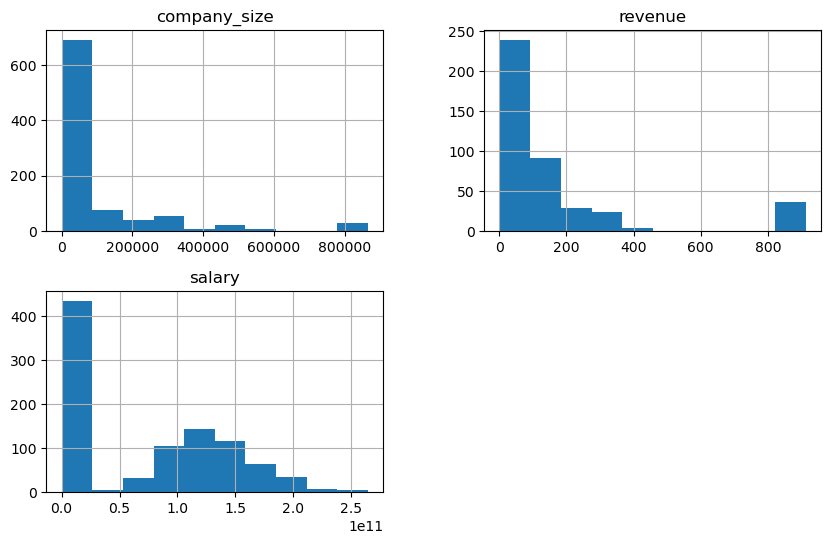

In [538]:
df[['salary', 'company_size', 'revenue']].head()
df.hist(figsize=(10,6))
plt.show()

## Visualize Relationships

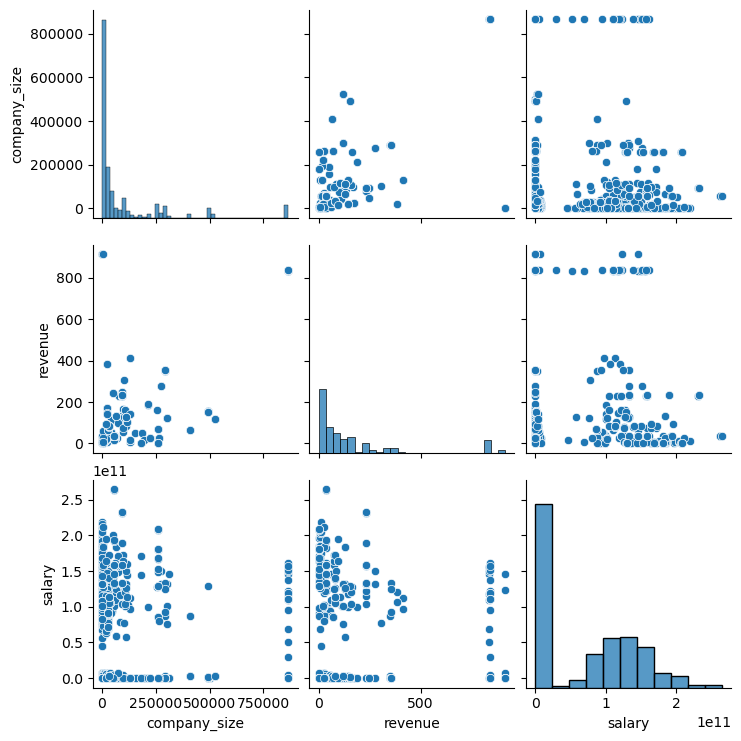

In [541]:
sns.pairplot(df.select_dtypes('number'))
plt.show()



## Correlation heatmap

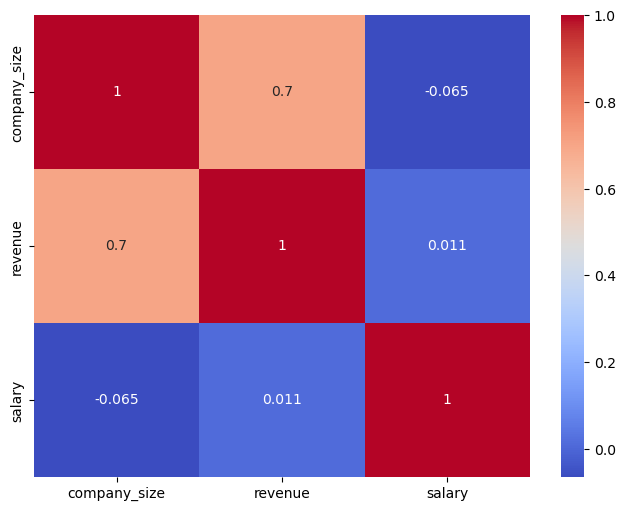

In [544]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## What it shows:

Each cell represents the correlation coefficient (r) between two numeric columns (e.g., between salary and company_size).

Values range from -1 to +1:

+1 → perfect positive correlation (as one increases, the other does too)

-1 → perfect negative correlation (as one increases, the other decreases)

0 → no linear relationship

## What the colors mean:

Red tones (coolwarm colormap): strong positive correlation

Blue tones: strong negative correlation

White/neutral: weak or no correlation

## Aggregation & Grouping:

The categorical columns (like industry, location, etc.), you can combine them with the numeric ones

This helps you identify top industries, cities, or companies by pay, size, etc.

In [548]:
df.groupby('industry')['salary'].mean().sort_values(ascending=False)

industry
Energy           1.082724e+11
Retail           1.019051e+11
Healthcare       7.080786e+10
Technology       6.659187e+10
Finance          6.636510e+10
Logistics        4.566834e+10
Manufacturing    3.956265e+10
Education        3.887621e+10
Name: salary, dtype: float64

## Data Cleaning & Transformation

In [551]:
# Select only numeric columns
df_numeric = df.select_dtypes(include=['number'])


In [553]:
# Check what we got
print(df_numeric.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_size  929 non-null    float64
 1   revenue       423 non-null    float64
 2   salary        944 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 22.3 KB
None


## Convert All Numeric Columns to Integers

In [556]:
# Convert all numeric columns to integers
df_numeric = df.select_dtypes(include=['number']).copy()

In [558]:
# Convert floats to integers (handling NaN safely)
df_numeric = df_numeric.fillna(0).astype(int)

In [560]:
# Check results
df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_size  944 non-null    int64
 1   revenue       944 non-null    int64
 2   salary        944 non-null    int64
dtypes: int64(3)
memory usage: 22.3 KB


## Find all numerical columns

In [563]:
numeric_cols = df.select_dtypes(include=['number']).columns
print(numeric_cols)

Index(['company_size', 'revenue', 'salary'], dtype='object')


In [565]:
missing_values = df[numeric_cols].isnull().sum()
print(missing_values)

company_size     15
revenue         521
salary            0
dtype: int64


In [567]:
missing_values = df[numeric_cols].isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

company_size     15
revenue         521
dtype: int64


In [569]:
# Fill with mean
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [571]:
print(df[numeric_cols].isnull().sum())

company_size    0
revenue         0
salary          0
dtype: int64


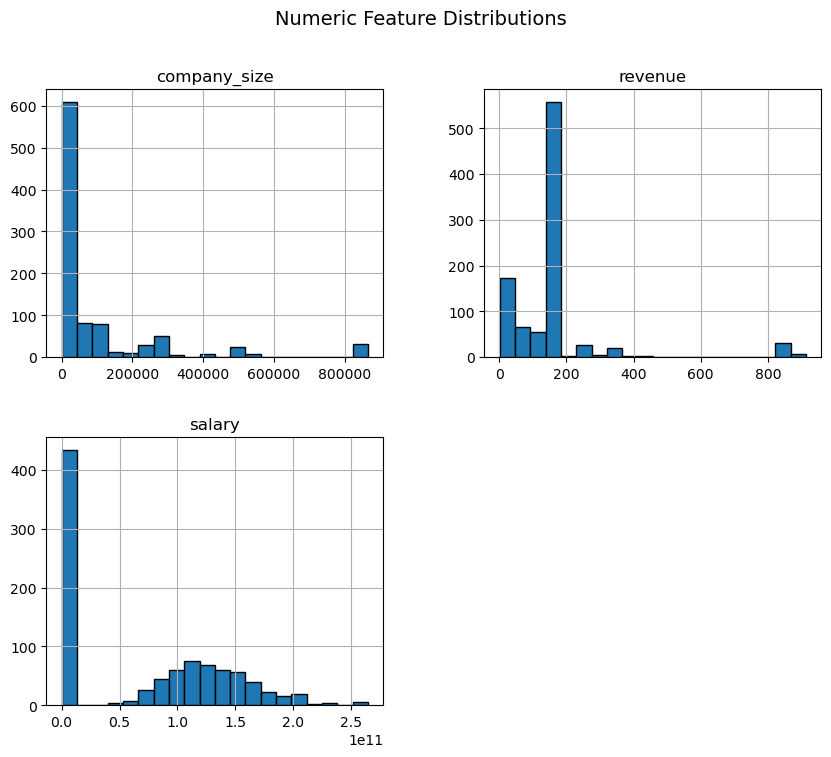

In [573]:
df[numeric_cols].hist(figsize=(10, 8), bins=20, edgecolor='black')
plt.suptitle('Numeric Feature Distributions', fontsize=14)
plt.show()


## Why scale:
It ensures all numeric columns are on similar scales (e.g., 0–1 or standard deviation units), which helps algorithms like KNN, logistic regression, and clustering.

In [576]:
# Remove duplicates if any
df.drop_duplicates(inplace=True)

# Normalize or scale (useful for ML)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

## Explore relationships, trends, and patterns:

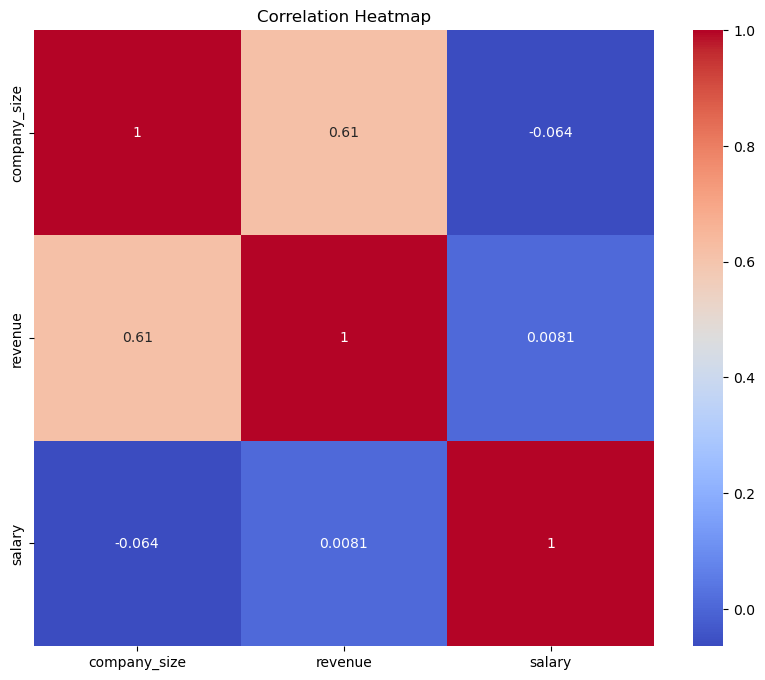

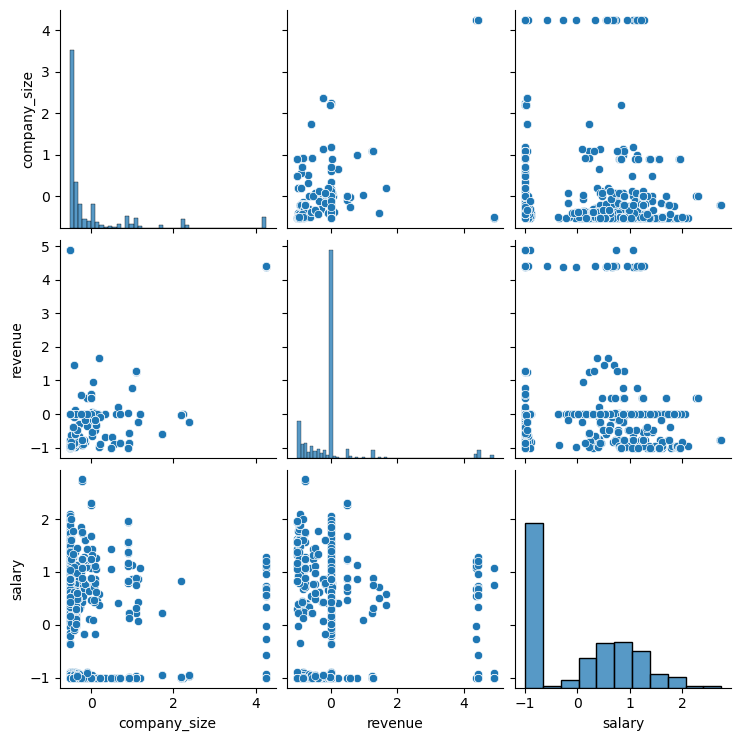

In [579]:

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Pairplot to visualize relationships
sns.pairplot(df[numeric_cols])
plt.show()

## Heatmap and Pairplot Show You Find:
Heatmap	Numeric correlation strength (matrix)	Linear relationships between all features

Pairplot	Scatterplots between pairs of features

## heatmap shows:

Each cell represents how strongly two numeric columns are related.

Color = strength & direction of the correlation

🔴 Red (or warm) → strong positive correlation (+1)
→ as one increases, the other increases (e.g., height & weight)

🔵 Blue (or cool) → strong negative correlation (–1)
→ as one increases, the other decreases (e.g., age & hours_of_sleep)

⚪ Near white (≈ 0) → no linear relationship

## Pairplot shows:
Pairplot does:

Creates a grid of scatterplots showing every pair of numeric columns plotted against each other.

On the diagonal, you’ll see histograms of each variable’s distribution.

What you see:

Each off-diagonal scatterplot shows how two variables relate.

A linear upward trend = positive correlation.

A downward trend = negative correlation.

A cloud of random points = no clear relationship.

How to interpret:

You can visually confirm relationships the heatmap suggests.

You can also spot outliers or nonlinear patterns.

## Statistical Analysis

In [585]:
df[numeric_cols].describe()

,company_size,revenue,salary
count,9.440000e+02,9.440000e+02,9.440000e+02
mean,-3.010774e-17,1.354848e-16,1.317214e-17
std,1.000530e+00,1.000530e+00,1.000530e+00
min,-5.225391e-01,-1.006011e+00,-1.001534e+00
25%,-5.167365e-01,-4.803655e-01,-1.001532e+00
50%,-4.136459e-01,1.837381e-16,1.250156e-01
75%,-1.131891e-03,1.837381e-16,8.609891e-01
max,4.248942e+00,4.891032e+00,2.747484e+00


## Machine Learning: Modeling


### Prepare your data:
X → your numeric feature columns (predictors)

y → your target column (what you want to predict)

In [589]:

# Suppose your target is 'salary'
target = 'salary'   # 🔁 change this to your actual column

# X = all numeric columns except target
X = df.select_dtypes(include=['number']).drop(columns=[target], errors='ignore')
y = df[target]

In [592]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (944, 2)
y shape: (944,)


In [594]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns:", numeric_cols)

Numeric columns: Index(['company_size', 'revenue', 'salary'], dtype='object')


In [596]:
y = df['salary']   # or whatever your target column is
X = df.drop(columns=['salary'])

In [598]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (944, 12)
y shape: (944,)


## Split into train/test sets


In [601]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scale numeric features

KNN is distance-based, so features must be on the same scale:

In [604]:
X_train.select_dtypes(include='object').head()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,skills
244,machine learning engineer,senior,on-site,company_465,"Washington, DC . On-site",14 days ago,"San Francisco, CA, US",Technology,Private,"['deep learning', 'aws', 'machine learning', '..."
82,machine learning engineer,NaN,on-site,company_156,"Mountain View, California (HQ) . On-site",8 days ago,"Mountain View, CA, US",Technology,Private,[]
316,data scientist,lead,on-site,company_640,United States,14 days ago,"Coraopolis, PA, US",Retail,Public,"['pytorch', 'spark', 'python', 'machine learni..."
350,data scientist,junior,on-site,company_723,"Miami, FL",14 days ago,"Chicago, IL, US",Finance,Private,"['pandas', 'spark', 'r', 'python', 'scikit-lea..."
465,machine learning engineer,senior,NaN,company_371,"South San Francisco, CA",7 days ago,"South San Francisco, CA, US",Healthcare,Private,"['pytorch', 'deep learning', 'machine learning..."


In [607]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)


In [609]:

# Make sure both train and test have the same columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [612]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [615]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

## Evaluate

For regression:

In [618]:

from sklearn.metrics import mean_squared_error, r2_score
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 1.852131822738042
R²: -0.8781096248263534


## Mean Squared Error (MSE = 1.85)

This means the average squared difference between the actual (y_test) and predicted (y_pred) values is about 1.85.

The closer this number is to 0, the better your predictions.

Interpretation:

Your model’s predictions are not close to the real values on average — an MSE near 1.85 suggests the model is making relatively large errors.

The actual size of the error depends on the scale of your target variable.

If your target (e.g., salary or price) is around 0–10, an MSE of 1.85 is quite poor.

If it’s around 0–1000, it might be acceptable.

## 2. R² Score = -0.8781

This is the key warning sign.

Normally:

R² = 1.0 → perfect prediction

R² = 0.0 → model is no better than predicting the mean of y_test

R² < 0.0 → model performs worse than just guessing the mean value of the target!

So, an R² of -0.88 means:

Your KNN model’s predictions are worse than a naive model that just predicts the average of the target variable every time.

# Important:
## If you’re doing Regression (predicting continuous values)

Examples: predicting price, age, temperature, or income.

Common Metrics:
Metric	Meaning	When to use	Good value
MSE (Mean Squared Error)	Average squared difference between actual and predicted. Penalizes large errors heavily.	When large errors are extra bad (e.g. predicting house prices).	Closer to 0 is better
RMSE (Root MSE)	Square root of MSE. Same scale as target variable.	Easier to interpret than MSE.	Lower = better
MAE (Mean Absolute Error)	Average absolute difference between actual and predicted.	When all errors matter equally (robust to outliers).	Lower = better
R² (Coefficient of Determination)	How well your model explains the variance in data.	When you want a single goodness-of-fit number.	1.0 = perfect; 0 = mean-only; negative = bad

Rule of thumb:

Start with R² to see how much variance your model explains.

Compare MAE and RMSE to understand the average error size.

In [623]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

MSE: 1.852131822738042
RMSE: 1.3609304988639361
MAE: 1.1016864740076475
R²: -0.8781096248263534


# What This Means

Your KNN model did not learn meaningful patterns from your data.
Possible causes:

❌ No informative features — your X data might not include the right predictors for y.

⚖️ Data scaling issues — though you scaled, maybe your features are mostly zero or have no variance.

⚙️ Wrong model type — maybe you used KNN when a linear or tree-based model fits the relationship better.

🧩 Bad hyperparameter choice — maybe n_neighbors is too high or too low.

🎯 Noise in target variable — the target might not have a strong relationship with the features

## Neural Network

In [640]:
# Initialize and train the neural network
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)


MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

In [641]:
# Generate predictions
y_pred = mlp.predict(X_test_scaled)

In [644]:
# Evaluate model performance
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 0.5472538907263034
R²: 0.44507038495925244


### MSE = 0.547 → On average, the squared difference between predicted and true values is about 0.55 units².
If your target variable is normalized or small in scale, that’s quite decent.

### R² = 0.445 → The model explains about 44.5% of the variance in the target variable.
That means nearly half of the variation in your target is captured by the model — a moderately good fit, depending on your data’s complexity and noise level.

# Random Forest

In [659]:
# Initialize the model
rf = RandomForestRegressor(
    n_estimators=100,   # Number of trees
    max_depth=None,     # Let trees grow until all leaves are pure or min_samples_split reached
    random_state=42,    # For reproducibility
    n_jobs=-1           # Use all CPU cores
)

In [661]:
# Fit the model on your training data
rf.fit(X_train_scaled, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [663]:
# Make predictions
y_pred = rf.predict(X_test_scaled)

In [665]:
# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [667]:

print("Random Forest Regression Results:")
print("MSE:", mse)
print("RMSE:", mse ** 0.5)
print("R²:", r2)

Random Forest Regression Results:
MSE: 0.49611782678494315
RMSE: 0.7043563208951441
R²: 0.49692367784314007


## Explanation: 
MSE (0.496) measures the average squared difference between predicted and actual values; lower is better.

RMSE (0.704) is the square root of MSE, showing that predictions deviate from true values by about 0.7 units on average.

R² (0.497) indicates the model explains roughly 50% of the variance in the target variable.

These metrics suggest the Random Forest model captures meaningful patterns but still misses some variability.

Performance can be improved with feature engineering, hyperparameter tuning, or more advanced ensemble methods.